# Quant Pricing — fonctions et graphes

Reprend toutes les fonctions de `lecture3-grezlak.py` (GBM, Black-Scholes fermé, pricers Monte-Carlo call/put, variance antithétique, convergence MC, parité call-put, greeks) et ajoute un plot par fonction/étude.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

from bs import call_bs, put_bs, delta
from mc_engine import (
    gbm,
    pricer_mc_call,
    pricer_mc_put,
    gbm_antithetic,
    pricer_mc_call_av,
    delta_mc,
)

PARAMS = dict(S0=100, K=100, sigma=0.2, r=0.05, T=1)
np.random.seed(42)

## 1. `gbm` — distribution du sous-jacent simulé

Histogramme de $S_T$ simulé par mouvement brownien géométrique, comparé à la densité log-normale théorique.

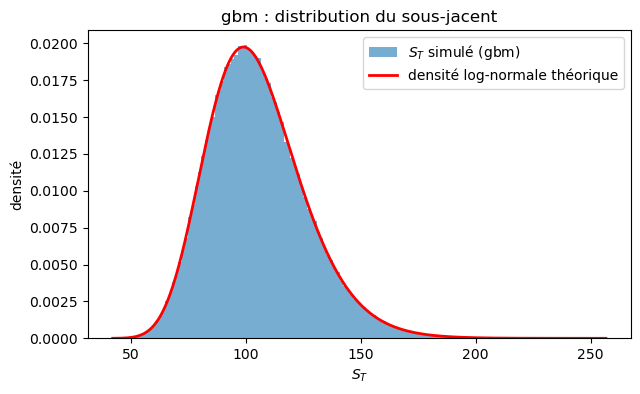

In [2]:
S0, K, sigma, r, T = PARAMS["S0"], PARAMS["K"], PARAMS["sigma"], PARAMS["r"], PARAMS["T"]
ST = gbm(S0, sigma, r, T, N=200_000)

x = np.linspace(ST.min(), ST.max(), 500)
mu = np.log(S0) + (r - 0.5*sigma**2)*T
pdf = norm.pdf(np.log(x), loc=mu, scale=sigma*np.sqrt(T)) / x

plt.figure(figsize=(7,4))
plt.hist(ST, bins=150, density=True, alpha=0.6, label="$S_T$ simulé (gbm)")
plt.plot(x, pdf, 'r-', lw=2, label="densité log-normale théorique")
plt.xlabel("$S_T$"); plt.ylabel("densité"); plt.title("gbm : distribution du sous-jacent")
plt.legend(); plt.show()

## 2. `call_bs` / `put_bs` — prix Black-Scholes fermé vs strike

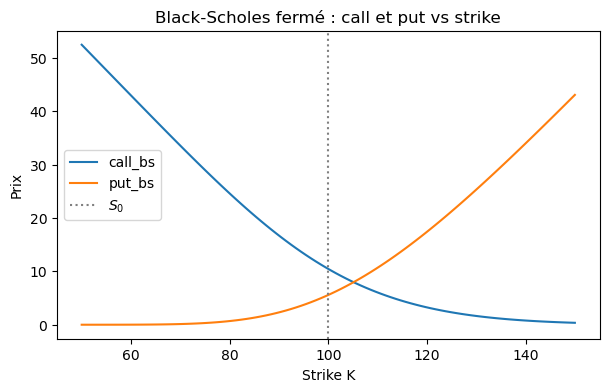

In [3]:
strikes = np.linspace(50, 150, 100)
call_prices = [call_bs(S0, k, sigma, r, T) for k in strikes]
put_prices = [put_bs(S0, k, sigma, r, T) for k in strikes]

plt.figure(figsize=(7,4))
plt.plot(strikes, call_prices, label="call_bs")
plt.plot(strikes, put_prices, label="put_bs")
plt.axvline(S0, color='grey', ls=':', label="$S_0$")
plt.xlabel("Strike K"); plt.ylabel("Prix"); plt.title("Black-Scholes fermé : call et put vs strike")
plt.legend(); plt.show()

## 3. `pricer_mc_call` / `pricer_mc_put` — prix MC vs BS avec IC 95%

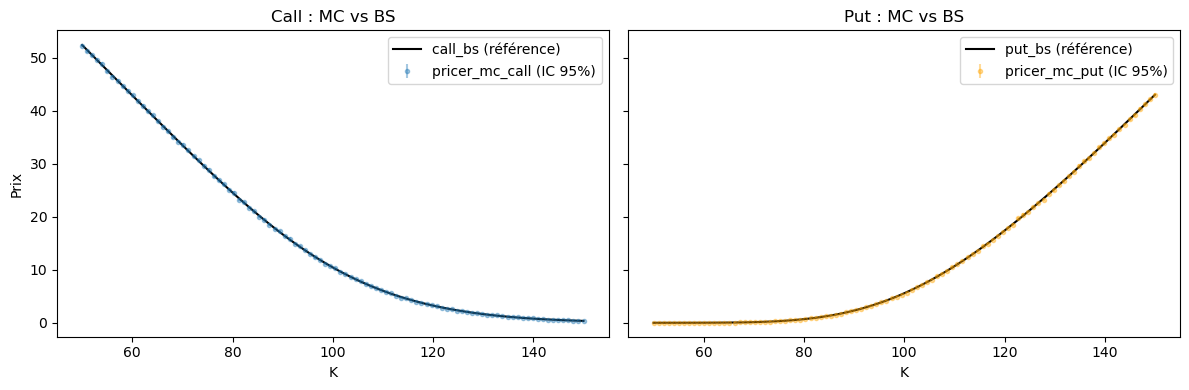

In [4]:
mc_call_prices, mc_call_ci = [], []
mc_put_prices, mc_put_ci = [], []
for k in strikes:
    p_c, ci_c = pricer_mc_call(S0, k, sigma, r, T, N=20_000)
    p_p, ci_p = pricer_mc_put(S0, k, sigma, r, T, N=20_000)
    mc_call_prices.append(p_c); mc_call_ci.append(ci_c)
    mc_put_prices.append(p_p); mc_put_ci.append(ci_p)

fig, axes = plt.subplots(1, 2, figsize=(12,4), sharey=True)
axes[0].plot(strikes, call_prices, 'k-', label="call_bs (référence)")
axes[0].errorbar(strikes, mc_call_prices, yerr=mc_call_ci, fmt='.', alpha=0.4, label="pricer_mc_call (IC 95%)")
axes[0].set_title("Call : MC vs BS"); axes[0].set_xlabel("K"); axes[0].set_ylabel("Prix"); axes[0].legend()

axes[1].plot(strikes, put_prices, 'k-', label="put_bs (référence)")
axes[1].errorbar(strikes, mc_put_prices, yerr=mc_put_ci, fmt='.', alpha=0.4, color='orange', label="pricer_mc_put (IC 95%)")
axes[1].set_title("Put : MC vs BS"); axes[1].set_xlabel("K"); axes[1].legend()
plt.tight_layout(); plt.show()

## 4. Convergence Monte-Carlo en $1/\sqrt{N}$

Erreur $|MC - BS|$ en fonction du nombre de trajectoires, en échelle log-log, comparée à la pente théorique $-1/2$.

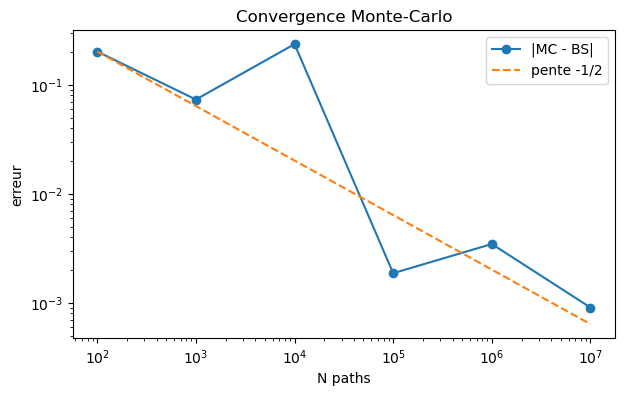

In [5]:
Ns = [100, 1_000, 10_000, 100_000, 1_000_000, 10_000_000]
bs_ref = call_bs(**PARAMS)

errors = []
for N in Ns:
    price, _ = pricer_mc_call(**PARAMS, N=N)
    errors.append(abs(price - bs_ref))

plt.figure(figsize=(7,4))
plt.loglog(Ns, errors, 'o-', label='|MC - BS|')
plt.loglog(Ns, [errors[0]*np.sqrt(Ns[0]/N) for N in Ns], '--', label='pente -1/2')
plt.xlabel('N paths'); plt.ylabel('erreur'); plt.title("Convergence Monte-Carlo")
plt.legend(); plt.show()

## 5. `gbm_antithetic` / `pricer_mc_call_av` — réduction de variance

Comparaison de la largeur de l'intervalle de confiance (donc de la variance de l'estimateur) entre Monte-Carlo standard et Monte-Carlo à variance antithétique, à budget de tirages comparable.

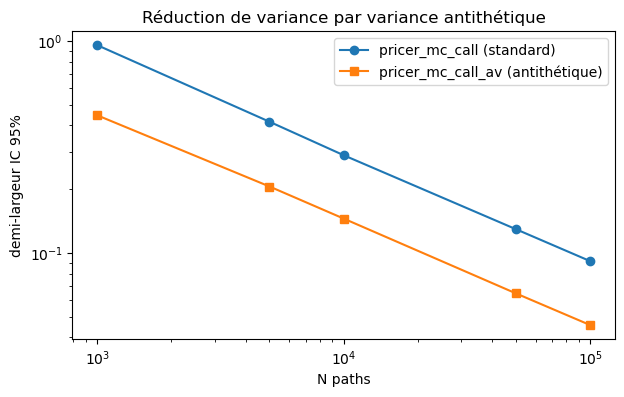

In [6]:
Ns_var = [1_000, 5_000, 10_000, 50_000, 100_000]
ci_std, ci_av = [], []
for N in Ns_var:
    _, c1 = pricer_mc_call(**PARAMS, N=N)
    _, c2 = pricer_mc_call_av(**PARAMS, N=N)
    ci_std.append(c1); ci_av.append(c2)

plt.figure(figsize=(7,4))
plt.loglog(Ns_var, ci_std, 'o-', label="pricer_mc_call (standard)")
plt.loglog(Ns_var, ci_av, 's-', label="pricer_mc_call_av (antithétique)")
plt.xlabel("N paths"); plt.ylabel("demi-largeur IC 95%")
plt.title("Réduction de variance par variance antithétique")
plt.legend(); plt.show()

## 6. Sanity check : parité call-put (BS fermé vs Monte-Carlo)

call_mc - put_mc : 4.8997063206950004
call_bs - put_bs : 4.877057549928594
S0 - K*exp(-rT)  : 4.877057549928594


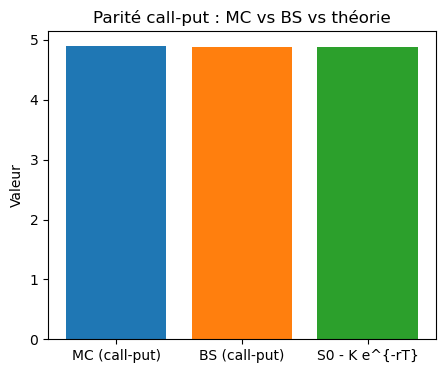

In [7]:
np.random.seed(42)
p1 = pricer_mc_call(**PARAMS)
np.random.seed(42)
p2 = pricer_mc_put(**PARAMS)

lhs_mc = p1[0] - p2[0]
lhs_bs = call_bs(**PARAMS) - put_bs(**PARAMS)
rhs = S0 - K*np.exp(-r*T)

print("call_mc - put_mc :", lhs_mc)
print("call_bs - put_bs :", lhs_bs)
print("S0 - K*exp(-rT)  :", rhs)
assert abs(lhs_mc - rhs) < 0.1, f"parité violée : {lhs_mc:.4f} vs {rhs:.4f}"

plt.figure(figsize=(5,4))
plt.bar(["MC (call-put)", "BS (call-put)", "S0 - K e^{-rT}"], [lhs_mc, lhs_bs, rhs], color=["C0","C1","C2"])
plt.title("Parité call-put : MC vs BS vs théorie")
plt.ylabel("Valeur"); plt.show()

## 7. `delta` / `delta_mc` — greek delta, théorique vs Monte-Carlo

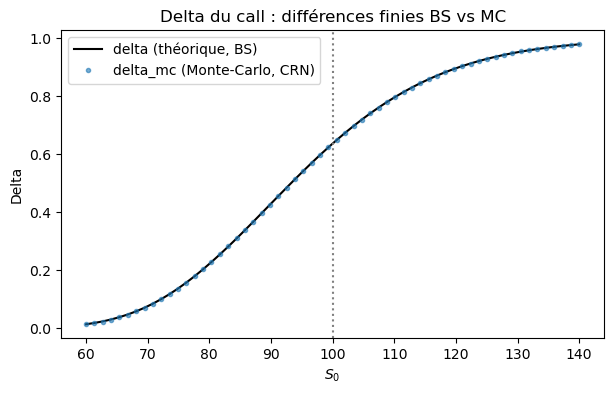

delta théorique (S0=100) : 0.636829791253426
delta monte carlo (S0=100) : 0.637535999860761


In [8]:
spots = np.linspace(60, 140, 60)
delta_theo = [delta(s, 0.1, K, sigma, r, T) for s in spots]
delta_mc_vals = [delta_mc(s, 0.1, K, sigma, r, T, N=50_000, seed=42) for s in spots]

plt.figure(figsize=(7,4))
plt.plot(spots, delta_theo, 'k-', label="delta (théorique, BS)")
plt.plot(spots, delta_mc_vals, '.', alpha=0.6, label="delta_mc (Monte-Carlo, CRN)")
plt.axvline(S0, color='grey', ls=':')
plt.xlabel("$S_0$"); plt.ylabel("Delta"); plt.title("Delta du call : différences finies BS vs MC")
plt.legend(); plt.show()

print("delta théorique (S0=100) :", delta(100, 0.1, K, sigma, r, T))
print("delta monte carlo (S0=100) :", delta_mc(100, 0.1, K, sigma, r, T))